# TBD Phase 2 26L: Performance & Computing Models

## Introduction
In this lab, you will compare the performance and computing models of four popular data processing libraries/engines: **Polars, Pandas, DuckDB, and PySpark**.

You will explore:
- **Performance**: single-node processing speed, parallel execution, memory usage, and result materialization cost.
- **Scalability**: how performance changes with the number of local threads/cores and with Spark executors on a cluster.
- **Physical layout**: how file format, Parquet layout, row groups, sorting, partitioning, and pruning affect IO.
- **Computing models**: in-memory vs. out-of-core processing, SQL vs. DataFrame APIs, eager vs. lazy execution, and streaming execution vs. streaming output.

This notebook is an assignment template. It gives you a common structure and helper code, but you must design your own dataset variant, queries, benchmark implementation, and analysis.


## Submission identity

Before starting the assignment, copy this notebook into your fork of the workshop repository and work on that copy.

Fill in the first code cell with:

- your group number,
- a link to this notebook in your forked GitHub repository,
- names or IDs of group members if required by the instructor.

The submitted notebook should be reachable from your fork. Do not submit a notebook that only exists locally.

In [1]:
GROUP_ID = 5
NOTEBOOK_URL = "https://github.com/kusmierzrafal/tbd-workshop-1/blob/master/notebooks/tbd_phase_2_26L.ipynb"
GROUP_MEMBERS = [
    "Paulina Staszewska",
    "Iga Bernat",
    "Rafał Kuśmierz",
]

assert GROUP_ID is not None, "Set GROUP_ID before running the notebook"
assert "<your-github-user-or-org>" not in NOTEBOOK_URL, "Set NOTEBOOK_URL to your forked repository notebook URL"

## Library/engine capabilities

Use this table as a reference when interpreting your results.

| Library/engine | Query optimizer | Distributed | Arrow-backed | Out-of-core | Parallel local execution | Main APIs |
|---|---|---|---|---|---|---|
| **Pandas 3.0** | no | no | default IO returns NumPy-backed data; `dtype_backend="pyarrow"` returns PyArrow-backed nullable dtypes | no | limited | DataFrame, `pd.col` for selected expression-style usage |
| **Polars** | yes | single-node locally; distributed engine is available in Polars Cloud and is outside this local benchmark | yes | yes | yes | DataFrame, lazy expressions, SQL subset |
| **DuckDB** | yes | no | yes | yes | yes | SQL, relational API |
| **PySpark** | yes | yes | yes, for selected IO/UDF paths | yes | yes | SQL, DataFrame |

The goal is not to prove that one library is always best. The goal is to identify which library/engine is appropriate for a given data size, query shape, memory limit, physical layout, and deployment model.

Use pandas 3.0 in this lab. Two pandas 3.0 behaviours matter for the benchmark: string columns are no longer inferred as generic `object` dtype by default, and Copy-on-Write is the only mutation model. In addition, compare two Pandas Parquet-reading variants where possible:

- default Pandas/NumPy-backed DataFrame: `pd.read_parquet(path)`,
- PyArrow-backed DataFrame: `pd.read_parquet(path, engine="pyarrow", dtype_backend="pyarrow")`.

Record the pandas version and dtypes in your report.


## Prerequisites

Install the required libraries in your notebook environment. If the course image already contains them, this command should be quick. Pandas 3.0 requires Python 3.11 or newer.

Use current Polars API in new code. In particular, use `collect(engine="streaming")` for streaming execution and use sink methods when you want to write streaming output to disk.

For Pandas, benchmark both the default backend and the PyArrow dtype backend for Parquet reads. The PyArrow-backed variant is especially relevant for string-heavy datasets.


In [2]:
%pip install -U "pandas>=3.0,<3.1" polars duckdb pyspark faker deltalake memory_profiler pyarrow psutil matplotlib seaborn

     ---------------------------------------- 0.0/455.4 MB ? eta -:--:--
     --------------------------------------- 3.7/455.4 MB 24.2 MB/s eta 0:00:19
      -------------------------------------- 7.9/455.4 MB 21.2 MB/s eta 0:00:22
     - ------------------------------------ 15.2/455.4 MB 26.6 MB/s eta 0:00:17
     - ------------------------------------ 19.1/455.4 MB 24.6 MB/s eta 0:00:18
     -- ----------------------------------- 24.4/455.4 MB 24.5 MB/s eta 0:00:18
     -- ----------------------------------- 30.4/455.4 MB 25.4 MB/s eta 0:00:17
     -- ----------------------------------- 34.9/455.4 MB 24.6 MB/s eta 0:00:18
     --- ---------------------------------- 40.1/455.4 MB 24.5 MB/s eta 0:00:17
     --- ---------------------------------- 44.6/455.4 MB 25.3 MB/s eta 0:00:17
     ---- --------------------------------- 49.0/455.4 MB 24.0 MB/s eta 0:00:17
     ---- --------------------------------- 55.1/455.4 MB 24.5 MB/s eta 0:00:17
     ----- -------------------------------- 61.

In [3]:
import gc
import os
import time
import json
import platform
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import polars as pl
import duckdb
import psutil
from faker import Faker
from memory_profiler import memory_usage
from pyspark.sql import SparkSession

print("Python:", platform.python_version())
if tuple(map(int, platform.python_version_tuple()[:2])) < (3, 11):
    raise RuntimeError("This notebook requires Python 3.11+ because it uses pandas 3.0.")
print("Polars:", pl.__version__)
print("Pandas:", pd.__version__)
if tuple(map(int, pd.__version__.split(".")[:2])) < (3, 0):
    raise RuntimeError("Install pandas 3.0+ before running the benchmark.")
print("DuckDB:", duckdb.__version__)
print("CPU logical cores:", psutil.cpu_count(logical=True))
print("RAM GiB:", round(psutil.virtual_memory().total / 2**30, 2))


Python: 3.11.15
Polars: 1.41.2
Pandas: 3.0.3
DuckDB: 1.5.3
CPU logical cores: 16
RAM GiB: 15.33


## Part 1: Data generation with group variants

Each group works with one assigned synthetic data profile. Use your group number to select the variant card below.

Your dataset does not need to match other groups exactly, but it must satisfy the common schema and benchmarking requirements described in this notebook.

Every group must document:
- dataset profile,
- main benchmark row count, plus any additional stress-test row counts if used,
- physical layout and file format choices,
- library versions,
- query intent,
- benchmark results,
- conclusions.

You may use the helper functions below, but you must adapt the dataset to your assigned variant.


## Variant cards for 16 groups

Choose or assign one variant per group.

| Group | Data profile | Required data feature | Suggested query stress |
|---:|---|---|---|
| 1 | Social media posts | tags or hashtags | explode/list handling, top-k |
| 2 | E-commerce orders | products and order values | join, category aggregation |
| 3 | IoT telemetry | device time series | time filters, rolling/window logic |
| 4 | Application logs | status codes and endpoints | selective filters, string columns |
| 5 | Advertising clicks | campaign skew | CTR, skewed group-by, join |
| 6 | Game events | player sessions | high-cardinality group-by |
| 7 | Streaming platform events | watch duration | device/country aggregation |
| 8 | Public transport events | route delays | time and location aggregation |
| 9 | Banking-like transactions | risk/fraud flags | selective filters, top-k, sorting |
| 10 | Web analytics | referrers and pages | funnel-like aggregation |
| 11 | Delivery/logistics events | late status updates | late events, time windows |
| 12 | Education platform activity | courses and students | joins and progress metrics |
| 13 | Weather measurements | missing values | resampling and null handling |
| 14 | Marketplace listings | prices and categories | quantiles, category statistics |
| 15 | Security events | rare alerts | selective filters and high skew |
| 16 | Support tickets | priority and SLA | time-to-resolution metrics |

You may rename columns and categories to fit the chosen profile. Keep enough common structure to run the same engine comparisons.

In [4]:
DOMAIN_CARDS = {
    1: {"name": "Social media posts", "feature": "tags", "stress": "explode/list handling and top-k"},
    2: {"name": "E-commerce orders", "feature": "products", "stress": "joins and category aggregation"},
    3: {"name": "IoT telemetry", "feature": "device time series", "stress": "time filters and rolling/window logic"},
    4: {"name": "Application logs", "feature": "status codes", "stress": "selective filters and string columns"},
    5: {"name": "Advertising clicks", "feature": "campaign skew", "stress": "CTR, skewed group-by, and joins"},
    6: {"name": "Game events", "feature": "player sessions", "stress": "high-cardinality group-by"},
    7: {"name": "Streaming platform events", "feature": "watch duration", "stress": "device/country aggregation"},
    8: {"name": "Public transport events", "feature": "route delays", "stress": "time and location aggregation"},
    9: {"name": "Banking-like transactions", "feature": "risk flags", "stress": "selective filters, top-k, and sorting"},
    10: {"name": "Web analytics", "feature": "referrers", "stress": "funnel-like aggregation"},
    11: {"name": "Delivery/logistics events", "feature": "late status updates", "stress": "late events and time windows"},
    12: {"name": "Education platform activity", "feature": "courses", "stress": "joins and progress metrics"},
    13: {"name": "Weather measurements", "feature": "missing values", "stress": "resampling and null handling"},
    14: {"name": "Marketplace listings", "feature": "prices", "stress": "quantiles and category statistics"},
    15: {"name": "Security events", "feature": "rare alerts", "stress": "selective filters and high skew"},
    16: {"name": "Support tickets", "feature": "priority and SLA", "stress": "time-to-resolution metrics"},
}

assert 1 <= GROUP_ID <= 16, "GROUP_ID must be between 1 and 16"
CARD = DOMAIN_CARDS[GROUP_ID]
CARD

{'name': 'Advertising clicks',
 'feature': 'campaign skew',
 'stress': 'CTR, skewed group-by, and joins'}

## Dataset requirements

Your generated dataset must contain at least:

- one timestamp column,
- one high-cardinality identifier, such as user, device, session, order, ticket, or transaction id,
- at least two categorical columns,
- at least two numeric metric columns,
- one feature specific to your variant card,
- enough rows to make local benchmark differences visible,
- a Parquet output file or directory.

Recommended starting sizes:

| Scale | Rows | Use case |
|---|---:|---|
| debug | 200,000 | Validate code quickly |
| small | 2,000,000 | Local development and first benchmark |
| medium | 10,000,000 to 20,000,000 | Main benchmark |
| large | 50,000,000+ | Optional stress test |

Use `debug` only while developing. The rendered notebook should report one main benchmark size (`N_ROWS`). If you run additional sizes, put those results in a separate stress-test table and do not mix them with the main benchmark table.

It is acceptable for different groups to generate different random data. Choose one main dataset size for the benchmark and record it as `N_ROWS`. You may use smaller debug data while developing and optional larger data for stress tests, but those extra sizes should be reported separately.

In [5]:
SCALE = "medium"
SCALE_ROWS = {
    "debug": 200_000,
    "small": 2_000_000,
    "medium": 10_000_000,
    "large": 50_000_000,
}

N_ROWS = SCALE_ROWS[SCALE]
OUTPUT_DIR = Path("../data/phase2_26L") / f"group_{GROUP_ID:02d}"
EVENTS_PATH = OUTPUT_DIR / "events.parquet"
PARTITIONED_EVENTS_DIR = OUTPUT_DIR / "events_partitioned"
OPTIMIZED_EVENTS_PATH = OUTPUT_DIR / "events_optimized.parquet"
DIMENSION_PATH = OUTPUT_DIR / "dimension.parquet"
MANIFEST_PATH = OUTPUT_DIR / "manifest.json"

# Required negative baseline paths for the file-format/layout task. Do not commit these generated files.
CSV_EVENTS_PATH = OUTPUT_DIR / "events.csv"
JSON_EVENTS_PATH = OUTPUT_DIR / "events.jsonl"

# Leave SEED as None if you want independent data on each generation.
# If you need to reproduce exactly the same dataset later, set SEED to the value stored in the manifest.
SEED = 42
RUN_SEED = int(np.random.SeedSequence().entropy) if SEED is None else int(SEED)
rng = np.random.default_rng(RUN_SEED)
fake = Faker()

print("Group:", GROUP_ID, CARD)
print("Rows:", N_ROWS)
print("Run seed recorded in manifest:", RUN_SEED)
print("Output directory:", OUTPUT_DIR)


Group: 5 {'name': 'Advertising clicks', 'feature': 'campaign skew', 'stress': 'CTR, skewed group-by, and joins'}
Rows: 10000000
Run seed recorded in manifest: 42
Output directory: ..\data\phase2_26L\group_05


## Generator template

The helper below creates a common base event table. You should extend it for your variant.

Do not spend most of the assignment writing a perfect data generator. The generator only needs to create data that is large enough and structurally interesting enough for your benchmark questions.

In [6]:
def skewed_ids(rng, n, max_id, hot_fraction=0.02, hot_probability=0.50):
    hot_count = max(1, int(max_id * hot_fraction))
    ids = rng.integers(hot_count + 1, max_id + 1, size=n)
    hot_mask = rng.random(n) < hot_probability
    ids[hot_mask] = rng.integers(1, hot_count + 1, size=hot_mask.sum())
    return ids


def random_tag_lists(rng, n, vocabulary=None, min_tags=1, max_tags=3):
    vocabulary = np.array(vocabulary or ["ai", "cloud", "spark", "polars", "duckdb", "sql", "etl", "security", "mlops"])
    counts = rng.integers(min_tags, max_tags + 1, size=n)
    tag_ids = rng.integers(0, len(vocabulary), size=(n, max_tags))
    return [[str(vocabulary[tag_ids[i, j]]) for j in range(counts[i])] for i in range(n)]


def generate_base_events(n, rng):
    start = np.datetime64("2026-01-01T00:00:00", "s")
    end = np.datetime64("2026-04-01T00:00:00", "s")
    seconds = int((end - start) / np.timedelta64(1, "s"))
    event_ts = (start + rng.integers(0, seconds, size=n).astype("timedelta64[s]")).astype("datetime64[us]")

    df = pl.DataFrame(
        {
            "event_id": np.arange(1, n + 1),
            "entity_id": skewed_ids(rng, n, max_id=200_000),
            "event_ts": event_ts,
            "category": rng.choice(["A", "B", "C", "D", "E", "F"], size=n),
            "country": rng.choice(["PL", "DE", "FR", "UK", "US", "IN", "BR"], size=n),
            "device": rng.choice(["mobile", "desktop", "tablet"], size=n, p=[0.65, 0.25, 0.10]),
            "metric_1": rng.lognormal(mean=4.0, sigma=1.0, size=n).round(3),
            "metric_2": rng.integers(0, 10_000, size=n),
            "tags": random_tag_lists(rng, n),
        }
    )
    return df.with_columns(pl.col("event_ts").dt.date().alias("event_date"))


def customize_for_variant(df, card, rng):
    n = df.height

    # Advertising clicks variant:
    # Each row represents one ad impression.
    # Required feature: campaign skew.
    campaign_ids = skewed_ids(
        rng,
        n=n,
        max_id=5_000,
        hot_fraction=0.03,
        hot_probability=0.65,
    )

    ad_ids = rng.integers(1, 50_000, size=n)

    placements = rng.choice(
        ["search", "social_feed", "video_pre_roll", "banner", "native"],
        size=n,
        p=[0.30, 0.30, 0.15, 0.15, 0.10],
    )

    ad_formats = rng.choice(
        ["text", "image", "video", "carousel"],
        size=n,
        p=[0.35, 0.35, 0.20, 0.10],
    )

    # CTR depends on placement and ad format.
    placement_ctr_boost = {
        "search": 0.045,
        "social_feed": 0.030,
        "video_pre_roll": 0.020,
        "banner": 0.012,
        "native": 0.025,
    }

    format_ctr_boost = {
        "text": 0.005,
        "image": 0.010,
        "video": 0.015,
        "carousel": 0.020,
    }

    click_probability = np.array([
        placement_ctr_boost[p] + format_ctr_boost[f]
        for p, f in zip(placements, ad_formats)
    ])

    click_probability = np.clip(
        click_probability + rng.normal(0, 0.005, size=n),
        0.001,
        0.20,
    )

    was_clicked = rng.random(n) < click_probability

    # Conversion can happen only after a click.
    conversion_probability = np.where(
        was_clicked,
        rng.uniform(0.01, 0.08, size=n),
        0.0,
    )

    was_converted = rng.random(n) < conversion_probability

    impression_cost = rng.lognormal(mean=-3.7, sigma=0.7, size=n)

    click_value = np.where(
        was_clicked,
        rng.lognormal(mean=0.8, sigma=0.8, size=n),
        0.0,
    )

    conversion_value = np.where(
        was_converted,
        rng.lognormal(mean=3.5, sigma=1.0, size=n),
        0.0,
    )

    return (
        df
        .rename({"entity_id": "user_id"})
        .with_columns([
            pl.Series("campaign_id", campaign_ids),
            pl.Series("ad_id", ad_ids),
            pl.Series("placement", placements),
            pl.Series("ad_format", ad_formats),
            pl.Series("impression_cost", impression_cost).round(5),
            pl.Series("was_clicked", was_clicked.astype(np.int8)),
            pl.Series("was_converted", was_converted.astype(np.int8)),
            pl.Series("click_value", click_value).round(2),
            pl.Series("conversion_value", conversion_value).round(2),
        ])
        .drop("tags")
    )


def generate_dimension_table(card, rng):
    n_campaigns = 5_000

    return pl.DataFrame({
        "campaign_id": np.arange(1, n_campaigns + 1),
        "advertiser_id": rng.integers(1, 500, size=n_campaigns),
        "campaign_type": rng.choice(
            ["brand_awareness", "performance", "retargeting", "lead_generation"],
            size=n_campaigns,
            p=[0.25, 0.40, 0.25, 0.10],
        ),
        "target_segment": rng.choice(
            ["students", "professionals", "parents", "gamers", "travelers"],
            size=n_campaigns,
            p=[0.18, 0.32, 0.20, 0.17, 0.13],
        ),
        "bid_strategy": rng.choice(
            ["cpc", "cpm", "cpa"],
            size=n_campaigns,
            p=[0.45, 0.40, 0.15],
        ),
        "daily_budget": rng.lognormal(
            mean=6.0,
            sigma=1.0,
            size=n_campaigns,
        ).round(2),
    })

In [7]:
# Generate and save the dataset after adapting the generator for Group 5: Advertising clicks.
# Generated data files are local artifacts and should not be committed to Git.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

base_events = generate_base_events(N_ROWS, rng)
events = customize_for_variant(base_events, CARD, rng)
dimension = generate_dimension_table(CARD, rng)

events.write_parquet(EVENTS_PATH, compression="zstd")
dimension.write_parquet(DIMENSION_PATH, compression="zstd")

# Optional partitioned layout for experiments with predicate pushdown and file layout.
events.write_parquet(PARTITIONED_EVENTS_DIR, partition_by="event_date", compression="zstd")

# Optimized Parquet layout for the selected query pattern is created and benchmarked
# later in Task 2.5. The OPTIMIZED_EVENTS_PATH entry remains in the manifest for reference.

manifest = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "group_id": GROUP_ID,
    "variant": CARD,
    "scale": SCALE,
    "rows": int(events.height),
    "run_seed": RUN_SEED,
    "paths": {
        "events": str(EVENTS_PATH),
        "events_partitioned": str(PARTITIONED_EVENTS_DIR),
        "events_optimized": str(OPTIMIZED_EVENTS_PATH),
        "dimension": str(DIMENSION_PATH),
    },
    "environment": {
        "python": platform.python_version(),
        "polars": pl.__version__,
        "pandas": pd.__version__,
        "duckdb": duckdb.__version__,
        "cpu_logical_cores": psutil.cpu_count(logical=True),
        "ram_gib": round(psutil.virtual_memory().total / 2**30, 2),
    },
}
MANIFEST_PATH.write_text(json.dumps(manifest, indent=2), encoding="utf-8")

print(json.dumps(manifest, indent=2))


{
  "created_at_utc": "2026-06-13T12:44:02.515798+00:00",
  "group_id": 5,
  "variant": {
    "name": "Advertising clicks",
    "feature": "campaign skew",
    "stress": "CTR, skewed group-by, and joins"
  },
  "scale": "medium",
  "rows": 10000000,
  "run_seed": 42,
  "paths": {
    "events": "..\\data\\phase2_26L\\group_05\\events.parquet",
    "events_partitioned": "..\\data\\phase2_26L\\group_05\\events_partitioned",
    "events_optimized": "..\\data\\phase2_26L\\group_05\\events_optimized.parquet",
    "dimension": "..\\data\\phase2_26L\\group_05\\dimension.parquet"
  },
  "environment": {
    "python": "3.11.15",
    "polars": "1.41.2",
    "pandas": "3.0.3",
    "duckdb": "1.5.3",
    "cpu_logical_cores": 16,
    "ram_gib": 15.33
  }
}


## Dataset sanity checks

Before benchmarking, inspect your schema and basic statistics. Your report should briefly explain why your dataset is suitable for the queries you chose.

In [8]:
# Load generated datasets back from Parquet
events = pl.read_parquet(EVENTS_PATH)
dimension = pl.read_parquet(DIMENSION_PATH)

print("Events shape:", events.shape)
print("Dimension shape:", dimension.shape)

events.head()

Events shape: (10000000, 18)
Dimension shape: (5000, 6)


event_id,user_id,event_ts,category,country,device,metric_1,metric_2,event_date,campaign_id,ad_id,placement,ad_format,impression_cost,was_clicked,was_converted,click_value,conversion_value
i64,i64,datetime[μs],str,str,str,f64,i64,date,i64,i64,str,str,f64,i8,i8,f64,f64
1,191889,2026-01-09 00:46:55,"""D""","""UK""","""mobile""",90.229,6707,2026-01-09,2287,46536,"""social_feed""","""text""",0.02436,0,0,0.0,0.0
2,8386,2026-03-11 15:44:42,"""A""","""UK""","""mobile""",74.715,9220,2026-03-11,40,23751,"""social_feed""","""text""",0.02056,0,0,0.0,0.0
3,126542,2026-02-28 21:52:28,"""F""","""US""","""mobile""",30.551,8009,2026-02-28,80,38235,"""social_feed""","""video""",0.00567,0,0,0.0,0.0
4,142772,2026-02-09 11:58:38,"""E""","""BR""","""mobile""",112.666,5204,2026-02-09,118,23684,"""banner""","""image""",0.01785,0,0,0.0,0.0
5,1473,2026-02-08 23:18:46,"""E""","""FR""","""mobile""",6.859,6563,2026-02-08,110,36496,"""social_feed""","""image""",0.00615,0,0,0.0,0.0


In [9]:
# Basic schema and dataset quality checks
print("Events schema:")
print(events.schema)

print("\nDimension schema:")
print(dimension.schema)

Events schema:
Schema([('event_id', Int64), ('user_id', Int64), ('event_ts', Datetime(time_unit='us', time_zone=None)), ('category', String), ('country', String), ('device', String), ('metric_1', Float64), ('metric_2', Int64), ('event_date', Date), ('campaign_id', Int64), ('ad_id', Int64), ('placement', String), ('ad_format', String), ('impression_cost', Float64), ('was_clicked', Int8), ('was_converted', Int8), ('click_value', Float64), ('conversion_value', Float64)])

Dimension schema:
Schema([('campaign_id', Int64), ('advertiser_id', Int64), ('campaign_type', String), ('target_segment', String), ('bid_strategy', String), ('daily_budget', Float64)])


In [10]:
# Basic dataset statistics
events.select([
    pl.len().alias("rows"),
    pl.col("user_id").n_unique().alias("unique_users"),
    pl.col("campaign_id").n_unique().alias("unique_campaigns"),
    pl.col("ad_id").n_unique().alias("unique_ads"),
    pl.col("event_date").min().alias("min_event_date"),
    pl.col("event_date").max().alias("max_event_date"),
    pl.col("was_clicked").sum().alias("clicks"),
    pl.col("was_converted").sum().alias("conversions"),
    (pl.col("was_clicked").sum() / pl.len()).alias("overall_ctr"),
    (pl.col("was_converted").sum() / pl.len()).alias("overall_conversion_rate"),
])

rows,unique_users,unique_campaigns,unique_ads,min_event_date,max_event_date,clicks,conversions,overall_ctr,overall_conversion_rate
u32,u32,u32,u32,date,date,i64,i64,f64,f64
10000000,200000,5000,49999,2026-01-01,2026-03-31,400368,18147,0.0400368,0.0018147


In [11]:
# Validate required feature: campaign skew
campaign_distribution = (
    events
    .group_by("campaign_id")
    .agg([
        pl.len().alias("impressions"),
        pl.col("was_clicked").sum().alias("clicks"),
        (pl.col("was_clicked").sum() / pl.len()).alias("ctr"),
        pl.col("impression_cost").sum().alias("total_cost"),
    ])
    .sort("impressions", descending=True)
)

campaign_distribution.head(20)

campaign_id,impressions,clicks,ctr,total_cost
i64,u32,i64,f64,f64
78,43910,1708,0.038898,1382.7147
46,43774,1718,0.039247,1382.96745
87,43737,1820,0.041612,1377.96345
134,43689,1697,0.038843,1373.71732
42,43689,1720,0.039369,1387.6206
…,…,…,…,…
129,43577,1750,0.040159,1373.84108
126,43574,1753,0.04023,1381.66423
72,43569,1731,0.03973,1373.41543


In [12]:
# Share of impressions generated by top campaigns
total_impressions = events.height

top_1pct_campaigns = max(1, int(campaign_distribution.height * 0.01))
top_5pct_campaigns = max(1, int(campaign_distribution.height * 0.05))

top_1pct_share = (
    campaign_distribution
    .head(top_1pct_campaigns)
    .select((pl.col("impressions").sum() / total_impressions).alias("top_1pct_impression_share"))
)

top_5pct_share = (
    campaign_distribution
    .head(top_5pct_campaigns)
    .select((pl.col("impressions").sum() / total_impressions).alias("top_5pct_impression_share"))
)

top_1pct_share, top_5pct_share

(shape: (1, 1)
 ┌───────────────────────────┐
 │ top_1pct_impression_share │
 │ ---                       │
 │ f64                       │
 ╞═══════════════════════════╡
 │ 0.2176883                 │
 └───────────────────────────┘,
 shape: (1, 1)
 ┌───────────────────────────┐
 │ top_5pct_impression_share │
 │ ---                       │
 │ f64                       │
 ╞═══════════════════════════╡
 │ 0.6575686                 │
 └───────────────────────────┘)

### Campaign skew validation

The required campaign skew is clearly visible in the generated medium dataset. The top 1% of campaigns generates about 21.8% of all impressions, while the top 5% generates about 65.8% of all impressions.

This makes the dataset suitable for testing skewed group-by operations, top-k queries, CTR calculations, and joins with the campaign dimension table.

## Part 2: Measuring performance

You must use one consistent benchmark protocol for all libraries/engines.

Minimum requirements:

1. Run every benchmark at least three times. Five repetitions are recommended.
2. Run `gc.collect()` before each measured repetition to reduce noise from previous Python allocations.
3. Report median runtime, not only one measurement.
4. Record peak memory where possible.
5. Check that results are logically equivalent across libraries/engines.
6. Store your results in a table.
7. Describe any library/engine-specific settings, such as Pandas dtype backend, thread count, Spark local mode, or DuckDB threads.

**Important for memory benchmarks**: notebook kernels keep allocations and library state between cells. Peak-RSS comparisons are often misleading when all variants run in the same process. For Task 3.1 and any memory-sensitive comparison, prefer running each variant in a fresh process or a small standalone script. If you cannot do that, clearly state this limitation.

You may use the helper shape below, but you need to implement the actual benchmark functions.


In [33]:
# Benchmark helper used by all local engines.
# Final memory measurements may be extended later, preferably in separate processes.

BENCHMARK_COLUMNS = [
    "library_engine",
    "mode",
    "query_name",
    "data_format",
    "layout",
    "rows",
    "median_time_s",
    "peak_memory_mb",
    "input_size_mb",
    "result_check",
    "notes",
]

benchmark_results = []

def file_size_mb(path):
    path = Path(path)
    if path.is_file():
        return round(path.stat().st_size / 1024 / 1024, 2)
    if path.is_dir():
        return round(
            sum(p.stat().st_size for p in path.rglob("*") if p.is_file()) / 1024 / 1024,
            2,
        )
    return None


def get_result_shape(result):
    if hasattr(result, "shape"):
        return result.shape
    if isinstance(result, list):
        return ("spark_collected_list", len(result))
    if hasattr(result, "count") and not isinstance(result, list):
        return ("spark_dataframe", result.count())
    return None


def benchmark_query(
    library_engine,
    mode,
    query_name,
    func,
    data_format="parquet",
    layout="default",
    rows=N_ROWS,
    input_path=EVENTS_PATH,
    runs=3,
    result_check="not checked yet",
    notes="",
):
    times = []
    last_result = None

    for _ in range(runs):
        gc.collect()

        start = time.perf_counter()
        last_result = func()
        end = time.perf_counter()

        times.append(end - start)

    record = {
        "library_engine": library_engine,
        "mode": mode,
        "query_name": query_name,
        "data_format": data_format,
        "layout": layout,
        "rows": rows,
        "median_time_s": round(float(np.median(times)), 6),
        "peak_memory_mb": None,
        "input_size_mb": file_size_mb(input_path),
        "result_check": result_check,
        "notes": notes,
    }

    benchmark_results.append(record)

    print(f"{library_engine} | {mode} | {query_name}")
    print(f"Runs: {[round(t, 6) for t in times]}")
    print(f"Median: {record['median_time_s']} s")
    print(f"Result shape: {get_result_shape(last_result)}")

    return last_result


def benchmark_results_df():
    return pd.DataFrame(benchmark_results, columns=BENCHMARK_COLUMNS)

## Part 3: Student tasks

### Task 1: Design three benchmark queries

Create three queries of your own choice. They must test different behavior.

Your queries should cover at least three of the following classes:

- selective filter plus aggregation,
- high-cardinality group-by,
- top-k or sorting,
- list/tag explode,
- join with a dimension table,
- window or rolling computation,
- query that produces a large output,
- query sensitive to partitioned vs. unpartitioned layout,
- query sensitive to column pruning, predicate pushdown, or row-group pruning.

For each query, write a short hypothesis before you run it:

- what does this query test?
- which library/engine do you expect to perform best?
- which library/engine may use the most memory?
- which physical layout should help, if any?


In [18]:
QUERY_SPECS = [
    {
        "query_id": "Q1",
        "query_name": "CTR by date, country and device",
        "query_type": "Selective filter + aggregation",
        "description": (
            "Filter advertising impression events to a selected date range and compute "
            "impressions, clicks, CTR, total cost and average conversion value by event_date, "
            "country and device."
        ),
        "stress_area": (
            "Predicate pushdown, column pruning, filtering by date, and medium-cardinality group-by."
        ),
        "expected_behavior": (
            "DuckDB and Polars lazy are expected to perform well because they can scan Parquet "
            "lazily and read only the required columns. Pandas may be slower or use more memory "
            "because it loads data eagerly."
        ),
    },
    {
        "query_id": "Q2",
        "query_name": "Top campaigns by impressions and CTR",
        "query_type": "Skewed high-cardinality group-by + top-k",
        "description": (
            "Group events by campaign_id and compute impressions, clicks, CTR, conversions, "
            "total impression cost and total conversion value. Return the top 100 campaigns "
            "by impression count."
        ),
        "stress_area": (
            "Required campaign skew, high-cardinality group-by, aggregation, sorting and top-k."
        ),
        "expected_behavior": (
            "This query should expose the campaign skew implemented in the data generator. "
            "DuckDB and Polars should handle it efficiently on local data. Spark may become "
            "more useful at larger scale, but local Spark can have higher overhead on debug data."
        ),
    },
    {
        "query_id": "Q3",
        "query_name": "Campaign performance by type and segment",
        "query_type": "Join + aggregation",
        "description": (
            "Join advertising events with the campaign dimension table by campaign_id and compute "
            "impressions, clicks, CTR, conversions, total cost and conversion value by campaign_type, "
            "target_segment and bid_strategy."
        ),
        "stress_area": (
            "Join execution, data enrichment, aggregation after join and materialization cost."
        ),
        "expected_behavior": (
            "DuckDB is expected to be strong for this SQL-style join. Polars lazy should also perform "
            "well due to query optimization. Spark should become more relevant when the dataset grows "
            "beyond comfortable single-node processing."
        ),
    },
]

pl.DataFrame(QUERY_SPECS)

query_id,query_name,query_type,description,stress_area,expected_behavior
str,str,str,str,str,str
"""Q1""","""CTR by date, country and devic…","""Selective filter + aggregation""","""Filter advertising impression …","""Predicate pushdown, column pru…","""DuckDB and Polars lazy are exp…"
"""Q2""","""Top campaigns by impressions a…","""Skewed high-cardinality group-…","""Group events by campaign_id an…","""Required campaign skew, high-c…","""This query should expose the c…"
"""Q3""","""Campaign performance by type a…","""Join + aggregation""","""Join advertising events with t…","""Join execution, data enrichmen…","""DuckDB is expected to be stron…"


### Task 2: Benchmark local libraries/engines

Implement your three queries in:

- Pandas 3.0 with the default NumPy-backed output from `pd.read_parquet(path)`,
- Pandas 3.0 with `pd.read_parquet(path, engine="pyarrow", dtype_backend="pyarrow")`,
- Polars,
- DuckDB,
- PySpark local mode.

For Polars, benchmark at least:

- eager execution,
- lazy execution with default collection,
- lazy execution with streaming engine.

For PySpark, use local mode in this task. Dataproc is a separate task later in the notebook.


In [19]:
# Configure Spark local for PySpark local benchmark.
# Local machine: 16 logical cores, 32 GB RAM.
# Start with local[4] to keep VS Code/Jupyter responsive.
# Later, scalability tests can compare local[1], local[2], local[4], local[*].

spark = (
    SparkSession.builder
    .appName("TBDPhase2LocalBenchmark")
    .master("local[4]")
    .config("spark.driver.memory", "6g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)

spark

In [20]:
# Pandas implementations of Q1-Q3.
# We implement both:
# 1. default backend: pd.read_parquet(path)
# 2. PyArrow backend: pd.read_parquet(path, engine="pyarrow", dtype_backend="pyarrow")

def read_events_pandas_default(events_path=EVENTS_PATH):
    return pd.read_parquet(events_path)


def read_events_pandas_pyarrow(events_path=EVENTS_PATH):
    return pd.read_parquet(
        events_path,
        engine="pyarrow",
        dtype_backend="pyarrow",
    )


def read_dimension_pandas_default(dimension_path=DIMENSION_PATH):
    return pd.read_parquet(dimension_path)


def read_dimension_pandas_pyarrow(dimension_path=DIMENSION_PATH):
    return pd.read_parquet(
        dimension_path,
        engine="pyarrow",
        dtype_backend="pyarrow",
    )


def q1_pandas_default(events_path=EVENTS_PATH):
    df = read_events_pandas_default(events_path)

    filtered = df[
        (df["event_date"] >= pd.to_datetime("2026-01-15").date()) &
        (df["event_date"] < pd.to_datetime("2026-03-01").date())
    ]

    result = (
        filtered
        .groupby(["event_date", "country", "device"], dropna=False)
        .agg(
            impressions=("event_id", "size"),
            clicks=("was_clicked", "sum"),
            total_cost=("impression_cost", "sum"),
            avg_conversion_value=("conversion_value", "mean"),
        )
        .reset_index()
    )

    result["ctr"] = result["clicks"] / result["impressions"]

    return (
        result[
            [
                "event_date",
                "country",
                "device",
                "impressions",
                "clicks",
                "ctr",
                "total_cost",
                "avg_conversion_value",
            ]
        ]
        .sort_values(["event_date", "country", "device"])
        .reset_index(drop=True)
    )


def q2_pandas_default(events_path=EVENTS_PATH):
    df = read_events_pandas_default(events_path)

    result = (
        df
        .groupby("campaign_id", dropna=False)
        .agg(
            impressions=("event_id", "size"),
            clicks=("was_clicked", "sum"),
            conversions=("was_converted", "sum"),
            total_cost=("impression_cost", "sum"),
            total_conversion_value=("conversion_value", "sum"),
        )
        .reset_index()
    )

    result["ctr"] = result["clicks"] / result["impressions"]

    return (
        result[
            [
                "campaign_id",
                "impressions",
                "clicks",
                "ctr",
                "conversions",
                "total_cost",
                "total_conversion_value",
            ]
        ]
        .sort_values("impressions", ascending=False)
        .head(100)
        .reset_index(drop=True)
    )


def q3_pandas_default(events_path=EVENTS_PATH, dimension_path=DIMENSION_PATH):
    events_df = read_events_pandas_default(events_path)
    dimension_df = read_dimension_pandas_default(dimension_path)

    joined = events_df.merge(
        dimension_df,
        on="campaign_id",
        how="inner",
    )

    result = (
        joined
        .groupby(["campaign_type", "target_segment", "bid_strategy"], dropna=False)
        .agg(
            impressions=("event_id", "size"),
            clicks=("was_clicked", "sum"),
            conversions=("was_converted", "sum"),
            total_cost=("impression_cost", "sum"),
            total_conversion_value=("conversion_value", "sum"),
        )
        .reset_index()
    )

    result["ctr"] = result["clicks"] / result["impressions"]

    return (
        result[
            [
                "campaign_type",
                "target_segment",
                "bid_strategy",
                "impressions",
                "clicks",
                "ctr",
                "conversions",
                "total_cost",
                "total_conversion_value",
            ]
        ]
        .sort_values("impressions", ascending=False)
        .reset_index(drop=True)
    )


def q1_pandas_pyarrow(events_path=EVENTS_PATH):
    df = read_events_pandas_pyarrow(events_path)

    filtered = df[
        (df["event_date"] >= pd.to_datetime("2026-01-15").date()) &
        (df["event_date"] < pd.to_datetime("2026-03-01").date())
    ]

    result = (
        filtered
        .groupby(["event_date", "country", "device"], dropna=False)
        .agg(
            impressions=("event_id", "size"),
            clicks=("was_clicked", "sum"),
            total_cost=("impression_cost", "sum"),
            avg_conversion_value=("conversion_value", "mean"),
        )
        .reset_index()
    )

    result["ctr"] = result["clicks"] / result["impressions"]

    return (
        result[
            [
                "event_date",
                "country",
                "device",
                "impressions",
                "clicks",
                "ctr",
                "total_cost",
                "avg_conversion_value",
            ]
        ]
        .sort_values(["event_date", "country", "device"])
        .reset_index(drop=True)
    )


def q2_pandas_pyarrow(events_path=EVENTS_PATH):
    df = read_events_pandas_pyarrow(events_path)

    result = (
        df
        .groupby("campaign_id", dropna=False)
        .agg(
            impressions=("event_id", "size"),
            clicks=("was_clicked", "sum"),
            conversions=("was_converted", "sum"),
            total_cost=("impression_cost", "sum"),
            total_conversion_value=("conversion_value", "sum"),
        )
        .reset_index()
    )

    result["ctr"] = result["clicks"] / result["impressions"]

    return (
        result[
            [
                "campaign_id",
                "impressions",
                "clicks",
                "ctr",
                "conversions",
                "total_cost",
                "total_conversion_value",
            ]
        ]
        .sort_values("impressions", ascending=False)
        .head(100)
        .reset_index(drop=True)
    )


def q3_pandas_pyarrow(events_path=EVENTS_PATH, dimension_path=DIMENSION_PATH):
    events_df = read_events_pandas_pyarrow(events_path)
    dimension_df = read_dimension_pandas_pyarrow(dimension_path)

    joined = events_df.merge(
        dimension_df,
        on="campaign_id",
        how="inner",
    )

    result = (
        joined
        .groupby(["campaign_type", "target_segment", "bid_strategy"], dropna=False)
        .agg(
            impressions=("event_id", "size"),
            clicks=("was_clicked", "sum"),
            conversions=("was_converted", "sum"),
            total_cost=("impression_cost", "sum"),
            total_conversion_value=("conversion_value", "sum"),
        )
        .reset_index()
    )

    result["ctr"] = result["clicks"] / result["impressions"]

    return (
        result[
            [
                "campaign_type",
                "target_segment",
                "bid_strategy",
                "impressions",
                "clicks",
                "ctr",
                "conversions",
                "total_cost",
                "total_conversion_value",
            ]
        ]
        .sort_values("impressions", ascending=False)
        .reset_index(drop=True)
    )

In [17]:
# Quick Pandas smoke test
pandas_default_q1_preview = q1_pandas_default()
pandas_default_q2_preview = q2_pandas_default()
pandas_default_q3_preview = q3_pandas_default()

pandas_pyarrow_q1_preview = q1_pandas_pyarrow()
pandas_pyarrow_q2_preview = q2_pandas_pyarrow()
pandas_pyarrow_q3_preview = q3_pandas_pyarrow()

print("Pandas default Q1:", pandas_default_q1_preview.shape)
print("Pandas default Q2:", pandas_default_q2_preview.shape)
print("Pandas default Q3:", pandas_default_q3_preview.shape)

print("Pandas PyArrow Q1:", pandas_pyarrow_q1_preview.shape)
print("Pandas PyArrow Q2:", pandas_pyarrow_q2_preview.shape)
print("Pandas PyArrow Q3:", pandas_pyarrow_q3_preview.shape)

pandas_default_q1_preview.head()

Pandas default Q1: (945, 8)
Pandas default Q2: (100, 7)
Pandas default Q3: (60, 9)
Pandas PyArrow Q1: (945, 8)
Pandas PyArrow Q2: (100, 7)
Pandas PyArrow Q3: (60, 9)


,event_date,country,device,impressions,clicks,ctr,total_cost,avg_conversion_value
0,2026-01-15,BR,desktop,3978,122,0.030669,125.50647,0.103107
1,2026-01-15,BR,mobile,10341,431,0.041679,329.40880,0.098060
2,2026-01-15,BR,tablet,1599,76,0.047530,51.41634,0.146667
3,2026-01-15,DE,desktop,3958,159,0.040172,122.18863,0.155912
4,2026-01-15,DE,mobile,10376,390,0.037587,327.62898,0.057943


In [21]:
# Polars implementations of Q1-Q3.
# Required modes:
# - eager: read_parquet -> transformations
# - lazy default: scan_parquet -> transformations -> collect()
# - lazy streaming: scan_parquet -> transformations -> collect(engine="streaming")

def q1_polars_eager(events_path=EVENTS_PATH):
    df = pl.read_parquet(events_path)

    return (
        df
        .filter(
            (pl.col("event_date") >= pl.date(2026, 1, 15)) &
            (pl.col("event_date") < pl.date(2026, 3, 1))
        )
        .group_by(["event_date", "country", "device"])
        .agg([
            pl.len().alias("impressions"),
            pl.col("was_clicked").sum().alias("clicks"),
            (pl.col("was_clicked").sum() / pl.len()).alias("ctr"),
            pl.col("impression_cost").sum().alias("total_cost"),
            pl.col("conversion_value").mean().alias("avg_conversion_value"),
        ])
        .sort(["event_date", "country", "device"])
    )


def q2_polars_eager(events_path=EVENTS_PATH):
    df = pl.read_parquet(events_path)

    return (
        df
        .group_by("campaign_id")
        .agg([
            pl.len().alias("impressions"),
            pl.col("was_clicked").sum().alias("clicks"),
            (pl.col("was_clicked").sum() / pl.len()).alias("ctr"),
            pl.col("was_converted").sum().alias("conversions"),
            pl.col("impression_cost").sum().alias("total_cost"),
            pl.col("conversion_value").sum().alias("total_conversion_value"),
        ])
        .sort("impressions", descending=True)
        .head(100)
    )


def q3_polars_eager(events_path=EVENTS_PATH, dimension_path=DIMENSION_PATH):
    events_df = pl.read_parquet(events_path)
    dimension_df = pl.read_parquet(dimension_path)

    return (
        events_df
        .join(dimension_df, on="campaign_id", how="inner")
        .group_by(["campaign_type", "target_segment", "bid_strategy"])
        .agg([
            pl.len().alias("impressions"),
            pl.col("was_clicked").sum().alias("clicks"),
            (pl.col("was_clicked").sum() / pl.len()).alias("ctr"),
            pl.col("was_converted").sum().alias("conversions"),
            pl.col("impression_cost").sum().alias("total_cost"),
            pl.col("conversion_value").sum().alias("total_conversion_value"),
        ])
        .sort("impressions", descending=True)
    )


def q1_polars_lazy(events_path=EVENTS_PATH):
    return (
        pl.scan_parquet(events_path)
        .filter(
            (pl.col("event_date") >= pl.date(2026, 1, 15)) &
            (pl.col("event_date") < pl.date(2026, 3, 1))
        )
        .group_by(["event_date", "country", "device"])
        .agg([
            pl.len().alias("impressions"),
            pl.col("was_clicked").sum().alias("clicks"),
            (pl.col("was_clicked").sum() / pl.len()).alias("ctr"),
            pl.col("impression_cost").sum().alias("total_cost"),
            pl.col("conversion_value").mean().alias("avg_conversion_value"),
        ])
        .sort(["event_date", "country", "device"])
        .collect()
    )


def q2_polars_lazy(events_path=EVENTS_PATH):
    return (
        pl.scan_parquet(events_path)
        .group_by("campaign_id")
        .agg([
            pl.len().alias("impressions"),
            pl.col("was_clicked").sum().alias("clicks"),
            (pl.col("was_clicked").sum() / pl.len()).alias("ctr"),
            pl.col("was_converted").sum().alias("conversions"),
            pl.col("impression_cost").sum().alias("total_cost"),
            pl.col("conversion_value").sum().alias("total_conversion_value"),
        ])
        .sort("impressions", descending=True)
        .limit(100)
        .collect()
    )


def q3_polars_lazy(events_path=EVENTS_PATH, dimension_path=DIMENSION_PATH):
    events_lf = pl.scan_parquet(events_path)
    dimension_lf = pl.scan_parquet(dimension_path)

    return (
        events_lf
        .join(dimension_lf, on="campaign_id", how="inner")
        .group_by(["campaign_type", "target_segment", "bid_strategy"])
        .agg([
            pl.len().alias("impressions"),
            pl.col("was_clicked").sum().alias("clicks"),
            (pl.col("was_clicked").sum() / pl.len()).alias("ctr"),
            pl.col("was_converted").sum().alias("conversions"),
            pl.col("impression_cost").sum().alias("total_cost"),
            pl.col("conversion_value").sum().alias("total_conversion_value"),
        ])
        .sort("impressions", descending=True)
        .collect()
    )


def q1_polars_streaming(events_path=EVENTS_PATH):
    return (
        pl.scan_parquet(events_path)
        .filter(
            (pl.col("event_date") >= pl.date(2026, 1, 15)) &
            (pl.col("event_date") < pl.date(2026, 3, 1))
        )
        .group_by(["event_date", "country", "device"])
        .agg([
            pl.len().alias("impressions"),
            pl.col("was_clicked").sum().alias("clicks"),
            (pl.col("was_clicked").sum() / pl.len()).alias("ctr"),
            pl.col("impression_cost").sum().alias("total_cost"),
            pl.col("conversion_value").mean().alias("avg_conversion_value"),
        ])
        .sort(["event_date", "country", "device"])
        .collect(engine="streaming")
    )


def q2_polars_streaming(events_path=EVENTS_PATH):
    return (
        pl.scan_parquet(events_path)
        .group_by("campaign_id")
        .agg([
            pl.len().alias("impressions"),
            pl.col("was_clicked").sum().alias("clicks"),
            (pl.col("was_clicked").sum() / pl.len()).alias("ctr"),
            pl.col("was_converted").sum().alias("conversions"),
            pl.col("impression_cost").sum().alias("total_cost"),
            pl.col("conversion_value").sum().alias("total_conversion_value"),
        ])
        .sort("impressions", descending=True)
        .limit(100)
        .collect(engine="streaming")
    )


def q3_polars_streaming(events_path=EVENTS_PATH, dimension_path=DIMENSION_PATH):
    events_lf = pl.scan_parquet(events_path)
    dimension_lf = pl.scan_parquet(dimension_path)

    return (
        events_lf
        .join(dimension_lf, on="campaign_id", how="inner")
        .group_by(["campaign_type", "target_segment", "bid_strategy"])
        .agg([
            pl.len().alias("impressions"),
            pl.col("was_clicked").sum().alias("clicks"),
            (pl.col("was_clicked").sum() / pl.len()).alias("ctr"),
            pl.col("was_converted").sum().alias("conversions"),
            pl.col("impression_cost").sum().alias("total_cost"),
            pl.col("conversion_value").sum().alias("total_conversion_value"),
        ])
        .sort("impressions", descending=True)
        .collect(engine="streaming")
    )

In [19]:
# Quick Polars smoke test
polars_eager_q1_preview = q1_polars_eager()
polars_eager_q2_preview = q2_polars_eager()
polars_eager_q3_preview = q3_polars_eager()

polars_lazy_q1_preview = q1_polars_lazy()
polars_lazy_q2_preview = q2_polars_lazy()
polars_lazy_q3_preview = q3_polars_lazy()

polars_streaming_q1_preview = q1_polars_streaming()
polars_streaming_q2_preview = q2_polars_streaming()
polars_streaming_q3_preview = q3_polars_streaming()

print("Polars eager Q1:", polars_eager_q1_preview.shape)
print("Polars eager Q2:", polars_eager_q2_preview.shape)
print("Polars eager Q3:", polars_eager_q3_preview.shape)

print("Polars lazy Q1:", polars_lazy_q1_preview.shape)
print("Polars lazy Q2:", polars_lazy_q2_preview.shape)
print("Polars lazy Q3:", polars_lazy_q3_preview.shape)

print("Polars streaming Q1:", polars_streaming_q1_preview.shape)
print("Polars streaming Q2:", polars_streaming_q2_preview.shape)
print("Polars streaming Q3:", polars_streaming_q3_preview.shape)

polars_lazy_q1_preview.head()

Polars eager Q1: (945, 8)
Polars eager Q2: (100, 7)
Polars eager Q3: (60, 9)
Polars lazy Q1: (945, 8)
Polars lazy Q2: (100, 7)
Polars lazy Q3: (60, 9)
Polars streaming Q1: (945, 8)
Polars streaming Q2: (100, 7)
Polars streaming Q3: (60, 9)


event_date,country,device,impressions,clicks,ctr,total_cost,avg_conversion_value
date,str,str,u32,i64,f64,f64,f64
2026-01-15,"""BR""","""desktop""",3978,122,0.030669,125.50647,0.103107
2026-01-15,"""BR""","""mobile""",10341,431,0.041679,329.4088,0.09806
2026-01-15,"""BR""","""tablet""",1599,76,0.04753,51.41634,0.146667
2026-01-15,"""DE""","""desktop""",3958,159,0.040172,122.18863,0.155912
2026-01-15,"""DE""","""mobile""",10376,390,0.037587,327.62898,0.057943


In [22]:
# DuckDB SQL implementations of Q1-Q3.
# DuckDB queries Parquet files directly without loading all data into Pandas first.

duckdb_con = duckdb.connect()

def q1_duckdb(events_path=EVENTS_PATH):
    return duckdb_con.execute(f"""
        SELECT
            event_date,
            country,
            device,
            COUNT(*) AS impressions,
            SUM(was_clicked) AS clicks,
            SUM(was_clicked)::DOUBLE / COUNT(*) AS ctr,
            SUM(impression_cost) AS total_cost,
            AVG(conversion_value) AS avg_conversion_value
        FROM read_parquet('{events_path}')
        WHERE event_date >= DATE '2026-01-15'
          AND event_date < DATE '2026-03-01'
        GROUP BY event_date, country, device
        ORDER BY event_date, country, device
    """).df()


def q2_duckdb(events_path=EVENTS_PATH):
    return duckdb_con.execute(f"""
        SELECT
            campaign_id,
            COUNT(*) AS impressions,
            SUM(was_clicked) AS clicks,
            SUM(was_clicked)::DOUBLE / COUNT(*) AS ctr,
            SUM(was_converted) AS conversions,
            SUM(impression_cost) AS total_cost,
            SUM(conversion_value) AS total_conversion_value
        FROM read_parquet('{events_path}')
        GROUP BY campaign_id
        ORDER BY impressions DESC
        LIMIT 100
    """).df()


def q3_duckdb(events_path=EVENTS_PATH, dimension_path=DIMENSION_PATH):
    return duckdb_con.execute(f"""
        SELECT
            d.campaign_type,
            d.target_segment,
            d.bid_strategy,
            COUNT(*) AS impressions,
            SUM(e.was_clicked) AS clicks,
            SUM(e.was_clicked)::DOUBLE / COUNT(*) AS ctr,
            SUM(e.was_converted) AS conversions,
            SUM(e.impression_cost) AS total_cost,
            SUM(e.conversion_value) AS total_conversion_value
        FROM read_parquet('{events_path}') e
        INNER JOIN read_parquet('{dimension_path}') d
            ON e.campaign_id = d.campaign_id
        GROUP BY d.campaign_type, d.target_segment, d.bid_strategy
        ORDER BY impressions DESC
    """).df()

In [21]:
# Quick DuckDB smoke test
duckdb_q1_preview = q1_duckdb()
duckdb_q2_preview = q2_duckdb()
duckdb_q3_preview = q3_duckdb()

print("DuckDB Q1:", duckdb_q1_preview.shape)
print("DuckDB Q2:", duckdb_q2_preview.shape)
print("DuckDB Q3:", duckdb_q3_preview.shape)

duckdb_q1_preview.head()

DuckDB Q1: (945, 8)
DuckDB Q2: (100, 7)
DuckDB Q3: (60, 9)


,event_date,country,device,impressions,clicks,ctr,total_cost,avg_conversion_value
0,2026-01-15,BR,desktop,3978,122.0,0.030669,125.50647,0.103107
1,2026-01-15,BR,mobile,10341,431.0,0.041679,329.40880,0.098060
2,2026-01-15,BR,tablet,1599,76.0,0.047530,51.41634,0.146667
3,2026-01-15,DE,desktop,3958,159.0,0.040172,122.18863,0.155912
4,2026-01-15,DE,mobile,10376,390.0,0.037587,327.62898,0.057943


In [29]:
# PySpark local implementations of Q1-Q3.

from pyspark.sql import functions as F

def q1_pyspark(events_path=EVENTS_PATH):
    df = spark.read.parquet(str(events_path))

    result = (
        df
        .filter(
            (F.col("event_date") >= F.lit("2026-01-15")) &
            (F.col("event_date") < F.lit("2026-03-01"))
        )
        .groupBy("event_date", "country", "device")
        .agg(
            F.count("*").alias("impressions"),
            F.sum("was_clicked").alias("clicks"),
            (F.sum("was_clicked") / F.count("*")).alias("ctr"),
            F.sum("impression_cost").alias("total_cost"),
            F.avg("conversion_value").alias("avg_conversion_value"),
        )
        .orderBy("event_date", "country", "device")
    )

    return result


def q2_pyspark(events_path=EVENTS_PATH):
    df = spark.read.parquet(str(events_path))

    result = (
        df
        .groupBy("campaign_id")
        .agg(
            F.count("*").alias("impressions"),
            F.sum("was_clicked").alias("clicks"),
            (F.sum("was_clicked") / F.count("*")).alias("ctr"),
            F.sum("was_converted").alias("conversions"),
            F.sum("impression_cost").alias("total_cost"),
            F.sum("conversion_value").alias("total_conversion_value"),
        )
        .orderBy(F.col("impressions").desc())
        .limit(100)
        .collect()
    )

    return result


def q3_pyspark(events_path=EVENTS_PATH, dimension_path=DIMENSION_PATH):
    events_df = spark.read.parquet(str(events_path))
    dimension_df = spark.read.parquet(str(dimension_path))

    result = (
        events_df
        .join(dimension_df, on="campaign_id", how="inner")
        .groupBy("campaign_type", "target_segment", "bid_strategy")
        .agg(
            F.count("*").alias("impressions"),
            F.sum("was_clicked").alias("clicks"),
            (F.sum("was_clicked") / F.count("*")).alias("ctr"),
            F.sum("was_converted").alias("conversions"),
            F.sum("impression_cost").alias("total_cost"),
            F.sum("conversion_value").alias("total_conversion_value"),
        )
        .orderBy(F.col("impressions").desc())
    )

    return result

In [23]:
# Quick PySpark smoke test

pyspark_q1_preview = q1_pyspark()
pyspark_q2_preview = q2_pyspark()
pyspark_q3_preview = q3_pyspark()

print("PySpark Q1:", (pyspark_q1_preview.count(), len(pyspark_q1_preview.columns)))
print("PySpark Q2:", (pyspark_q2_preview.count(), len(pyspark_q2_preview.columns)))
print("PySpark Q3:", (pyspark_q3_preview.count(), len(pyspark_q3_preview.columns)))

pyspark_q1_preview.show(5)

PySpark Q1: (945, 8)


PySpark Q2: (100, 7)


PySpark Q3: (60, 9)


+----------+-------+-------+-----------+------+--------------------+------------------+--------------------+
|event_date|country| device|impressions|clicks|                 ctr|        total_cost|avg_conversion_value|
+----------+-------+-------+-----------+------+--------------------+------------------+--------------------+
|2026-01-15|     BR|desktop|       3978|   122|0.030668677727501256|125.50646999999998| 0.10310708898944193|
|2026-01-15|     BR| mobile|      10341|   431| 0.04167875447248815| 329.4088000000005|  0.0980601489217677|
|2026-01-15|     BR| tablet|       1599|    76|0.047529706066291436|51.416339999999984| 0.14666666666666667|
|2026-01-15|     DE|desktop|       3958|   159| 0.04017180394138454|122.18863000000003|  0.1559120768064679|
|2026-01-15|     DE| mobile|      10376|   390| 0.03758673862760216| 327.6289800000003|0.057943330763299924|
+----------+-------+-------+-----------+------+--------------------+------------------+--------------------+
only showing top 5 

### Task 2.5: File format and Parquet layout optimization

Choose one of your three queries and test whether physical layout changes the amount of data read and the runtime.

Required comparison:

- default Parquet layout: randomly ordered data, one file or the default layout from your generator,
- optimized Parquet layout: choose a layout based on the query pattern, for example sorting by filter columns, changing `row_group_size`, partitioning by a selective column, or using writer-level pruning aids such as bloom filters if your writer and reader clearly support them,
- negative baseline: CSV or JSON/JSONL for the same query, to show what is lost without Parquet column pruning and predicate pushdown.

Use CSV if you do not have a strong reason to prefer JSON/JSONL. If your full dataset contains nested/list columns, create a flat query-specific CSV/JSON baseline containing only the columns needed by the selected query.

Report at least:

- file format and physical layout,
- total input size and number of files,
- runtime and peak memory,
- result checksum/equivalence,
- evidence of pruning where available: query plan, number of files read/skipped, row groups read/skipped, or a clear explanation if the engine does not expose these metrics.

Do not just create a faster layout accidentally. Explain why the layout should help this query.


In [24]:
# Task 2.5: File format and Parquet layout optimization
# Selected query: Q1 - CTR by date, country and device.
#
# Why Q1?
# Q1 uses a selective date filter and only a subset of columns.
# This makes it a good candidate for testing Parquet predicate pushdown,
# column pruning, and row-group pruning.

LAYOUT_EXPERIMENT_DIR = OUTPUT_DIR / "layout_experiment"
LAYOUT_EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

Q1_DEFAULT_PARQUET_PATH = EVENTS_PATH
Q1_OPTIMIZED_PARQUET_PATH = LAYOUT_EXPERIMENT_DIR / "events_q1_optimized_sorted_by_date.parquet"
Q1_CSV_PATH = LAYOUT_EXPERIMENT_DIR / "events_q1_baseline.csv"

Q1_COLUMNS = [
    "event_date",
    "country",
    "device",
    "event_id",
    "was_clicked",
    "impression_cost",
    "conversion_value",
]

# 1. Build optimized Parquet layout:
# sort by event_date because Q1 filters by event_date.
# Use smaller row groups to make row-group pruning more likely.
(
    events
    .select(Q1_COLUMNS)
    .sort("event_date")
    .write_parquet(
        Q1_OPTIMIZED_PARQUET_PATH,
        compression="zstd",
        row_group_size=25_000,
    )
)

# 2. Build CSV negative baseline:
# CSV stores the same query-specific flat subset of columns.
# It does not provide Parquet-style column pruning or row-group statistics.
(
    events
    .select(Q1_COLUMNS)
    .write_csv(Q1_CSV_PATH)
)

def count_files(path):
    path = Path(path)
    if path.is_file():
        return 1
    if path.is_dir():
        return sum(1 for p in path.rglob("*") if p.is_file())
    return 0


layout_summary = pd.DataFrame([
    {
        "layout_name": "default_parquet",
        "path": str(Q1_DEFAULT_PARQUET_PATH),
        "format": "parquet",
        "layout": "default generator output",
        "size_mb": file_size_mb(Q1_DEFAULT_PARQUET_PATH),
        "num_files": count_files(Q1_DEFAULT_PARQUET_PATH),
    },
    {
        "layout_name": "optimized_parquet",
        "path": str(Q1_OPTIMIZED_PARQUET_PATH),
        "format": "parquet",
        "layout": "selected Q1 columns, sorted by event_date, row_group_size=25_000",
        "size_mb": file_size_mb(Q1_OPTIMIZED_PARQUET_PATH),
        "num_files": count_files(Q1_OPTIMIZED_PARQUET_PATH),
    },
    {
        "layout_name": "csv_baseline",
        "path": str(Q1_CSV_PATH),
        "format": "csv",
        "layout": "flat CSV with Q1 columns only",
        "size_mb": file_size_mb(Q1_CSV_PATH),
        "num_files": count_files(Q1_CSV_PATH),
    },
])

layout_summary

,layout_name,path,format,layout,size_mb,num_files
0,default_parquet,../data/phase2_26L/group_05/events.parquet,parquet,default generator output,243.07,1
1,optimized_parquet,../data/phase2_26L/group_05/layout_experiment/...,parquet,"selected Q1 columns, sorted by event_date, row...",52.49,1
2,csv_baseline,../data/phase2_26L/group_05/layout_experiment/...,csv,flat CSV with Q1 columns only,410.38,1


In [25]:
# Benchmark Q1 on default Parquet, optimized Parquet, and CSV baseline.
# We use DuckDB because it can query Parquet and CSV directly.

def q1_duckdb_csv(csv_path=Q1_CSV_PATH):
    return duckdb_con.execute(f"""
        SELECT
            CAST(event_date AS DATE) AS event_date,
            country,
            device,
            COUNT(*) AS impressions,
            SUM(was_clicked) AS clicks,
            SUM(was_clicked)::DOUBLE / COUNT(*) AS ctr,
            SUM(impression_cost) AS total_cost,
            AVG(conversion_value) AS avg_conversion_value
        FROM read_csv_auto('{csv_path}')
        WHERE CAST(event_date AS DATE) >= DATE '2026-01-15'
          AND CAST(event_date AS DATE) < DATE '2026-03-01'
        GROUP BY CAST(event_date AS DATE), country, device
        ORDER BY event_date, country, device
    """).df()


layout_benchmark_results = []

def benchmark_layout_query(layout_name, data_format, layout, func, input_path, runs=3):
    times = []
    last_result = None

    for _ in range(runs):
        gc.collect()
        start = time.perf_counter()
        last_result = func()
        end = time.perf_counter()
        times.append(end - start)

    record = {
        "layout_name": layout_name,
        "data_format": data_format,
        "layout": layout,
        "runs": runs,
        "median_time_s": round(float(np.median(times)), 6),
        "input_size_mb": file_size_mb(input_path),
        "num_files": count_files(input_path),
        "result_rows": len(last_result),
        "impressions_checksum": int(last_result["impressions"].sum()),
        "clicks_checksum": int(last_result["clicks"].sum()),
        "total_cost_checksum": round(float(last_result["total_cost"].sum()), 4),
    }

    layout_benchmark_results.append(record)

    print(f"{layout_name}: {record['median_time_s']} s")
    return last_result


q1_default_layout_result = benchmark_layout_query(
    layout_name="default_parquet",
    data_format="parquet",
    layout="default generator output",
    func=lambda: q1_duckdb(Q1_DEFAULT_PARQUET_PATH),
    input_path=Q1_DEFAULT_PARQUET_PATH,
)

q1_optimized_layout_result = benchmark_layout_query(
    layout_name="optimized_parquet",
    data_format="parquet",
    layout="selected Q1 columns, sorted by event_date, row_group_size=25_000",
    func=lambda: q1_duckdb(Q1_OPTIMIZED_PARQUET_PATH),
    input_path=Q1_OPTIMIZED_PARQUET_PATH,
)

q1_csv_layout_result = benchmark_layout_query(
    layout_name="csv_baseline",
    data_format="csv",
    layout="flat CSV with Q1 columns only",
    func=lambda: q1_duckdb_csv(Q1_CSV_PATH),
    input_path=Q1_CSV_PATH,
)

layout_benchmark_df = pd.DataFrame(layout_benchmark_results)
layout_benchmark_df

default_parquet: 0.207664 s
optimized_parquet: 0.153688 s


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

csv_baseline: 2.736555 s


,layout_name,data_format,layout,runs,median_time_s,input_size_mb,num_files,result_rows,impressions_checksum,clicks_checksum,total_cost_checksum
0,default_parquet,parquet,default generator output,3,0.207664,243.07,1,945,5001582,200387,157888.0027
1,optimized_parquet,parquet,"selected Q1 columns, sorted by event_date, row...",3,0.153688,52.49,1,945,5001582,200387,157888.0027
2,csv_baseline,csv,flat CSV with Q1 columns only,3,2.736555,410.38,1,945,5001582,200387,157888.0027


### Task 2.5 results and interpretation

For the file format and layout experiment, Q1 was selected because it filters events by `event_date` and uses only a subset of columns. This makes it suitable for testing column pruning, predicate pushdown, and row-group pruning.

The optimized Parquet layout stores only Q1-related columns, is sorted by `event_date`, and uses `row_group_size=25_000`. This layout should help because Q1 applies a date range filter and does not need all columns from the full event dataset.

On the medium dataset, the optimized Parquet layout was faster than the default Parquet layout: 0.154 s versus 0.208 s median runtime. The CSV baseline was much slower at 2.737 s, despite containing only the Q1-related columns. This illustrates what is lost without Parquet metadata, columnar storage, and predicate pushdown support.

The input sizes also differed significantly: the default Parquet file was 243.07 MB, the optimized query-specific Parquet file was 52.49 MB, and the CSV baseline was 410.38 MB.

The result equivalence was verified using row counts and aggregate checksums. All three layouts returned 945 result rows, 5,001,582 impressions, 200,387 clicks, and the same total cost checksum.

### Task 3: Execution Modes & Analysis

**Goal**: deep dive into execution models, memory limits, and the decision boundary between single-node and distributed processing.

This task has three separate parts. Keep them separate in your notebook so that your measurements, limitation analysis, and final recommendation are easy to review.

#### 3.1 Lazy vs. eager vs. streaming

Use Polars to compare execution time and peak memory for the same logical operation in these modes:

- eager execution: `read_parquet` -> filter/transform,
- lazy execution: `scan_parquet` -> filter/transform -> `collect()`,
- streaming execution: `scan_parquet` -> filter/transform -> `collect(engine="streaming")`,
- streaming output: `scan_parquet` -> filter/transform -> `sink_parquet(...)`.

Important distinction:

- `collect(engine="streaming")` uses the streaming engine but still materializes the final result as a DataFrame.
- `sink_parquet(...)` or another sink writes the result to disk and is the better pattern when the output may be large.

Choose a query where this distinction matters. A tiny aggregate result may not show meaningful peak-memory differences. A better stress case keeps many rows, selects several columns, performs a non-trivial filter, and writes a large output.

**Run memory-sensitive variants in separate processes if possible.** If you run all modes in one notebook kernel, previous allocations and engine caches can hide the real memory difference. At minimum, call `gc.collect()` before each measured run and discuss the limitation.

If peak memory is almost identical across modes, increase the dataset size, increase the output size, measure each mode in a fresh process, or explain why your query is not memory-stressful enough.


In [26]:
# Task 3.1: Polars execution-mode experiment
#
# We use a large-output query instead of a small aggregate.
# The query filters events by date, selects several advertising-related columns,
# adds derived columns, and returns many rows.
#
# This makes the distinction between collect() and sink_parquet() meaningful:
# - collect() materializes the result as a DataFrame,
# - sink_parquet() writes the result to disk without keeping the final DataFrame in memory.

POLARS_MODE_EXPERIMENT_DIR = OUTPUT_DIR / "polars_mode_experiment"
POLARS_MODE_EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

POLARS_SINK_OUTPUT_PATH = POLARS_MODE_EXPERIMENT_DIR / "large_output_streaming_sink.parquet"

POLARS_MODE_COLUMNS = [
    "event_id",
    "user_id",
    "event_ts",
    "event_date",
    "country",
    "device",
    "campaign_id",
    "ad_id",
    "placement",
    "ad_format",
    "impression_cost",
    "was_clicked",
    "was_converted",
    "click_value",
    "conversion_value",
]


def polars_large_output_eager(events_path=EVENTS_PATH):
    df = pl.read_parquet(events_path)

    return (
        df
        .filter(
            (pl.col("event_date") >= pl.date(2026, 1, 15)) &
            (pl.col("event_date") < pl.date(2026, 3, 1))
        )
        .select(POLARS_MODE_COLUMNS)
        .with_columns([
            (pl.col("impression_cost") * pl.col("was_clicked")).alias("clicked_impression_cost"),
            (pl.col("conversion_value") - pl.col("impression_cost")).alias("net_value"),
            (
                pl.col("campaign_id").rank("dense").over("country")
            ).alias("campaign_rank_within_country"),
        ])
    )


def polars_large_output_lazy(events_path=EVENTS_PATH):
    return (
        pl.scan_parquet(events_path)
        .filter(
            (pl.col("event_date") >= pl.date(2026, 1, 15)) &
            (pl.col("event_date") < pl.date(2026, 3, 1))
        )
        .select(POLARS_MODE_COLUMNS)
        .with_columns([
            (pl.col("impression_cost") * pl.col("was_clicked")).alias("clicked_impression_cost"),
            (pl.col("conversion_value") - pl.col("impression_cost")).alias("net_value"),
            (
                pl.col("campaign_id").rank("dense").over("country")
            ).alias("campaign_rank_within_country"),
        ])
        .collect()
    )


def polars_large_output_streaming_collect(events_path=EVENTS_PATH):
    return (
        pl.scan_parquet(events_path)
        .filter(
            (pl.col("event_date") >= pl.date(2026, 1, 15)) &
            (pl.col("event_date") < pl.date(2026, 3, 1))
        )
        .select(POLARS_MODE_COLUMNS)
        .with_columns([
            (pl.col("impression_cost") * pl.col("was_clicked")).alias("clicked_impression_cost"),
            (pl.col("conversion_value") - pl.col("impression_cost")).alias("net_value"),
            (
                pl.col("campaign_id").rank("dense").over("country")
            ).alias("campaign_rank_within_country"),
        ])
        .collect(engine="streaming")
    )


def polars_large_output_streaming_sink(
    events_path=EVENTS_PATH,
    output_path=POLARS_SINK_OUTPUT_PATH,
):
    if Path(output_path).exists():
        Path(output_path).unlink()

    (
        pl.scan_parquet(events_path)
        .filter(
            (pl.col("event_date") >= pl.date(2026, 1, 15)) &
            (pl.col("event_date") < pl.date(2026, 3, 1))
        )
        .select(POLARS_MODE_COLUMNS)
        .with_columns([
            (pl.col("impression_cost") * pl.col("was_clicked")).alias("clicked_impression_cost"),
            (pl.col("conversion_value") - pl.col("impression_cost")).alias("net_value"),
            (
                pl.col("campaign_id").rank("dense").over("country")
            ).alias("campaign_rank_within_country"),
        ])
        .sink_parquet(output_path, compression="zstd")
    )

    return {
        "output_path": str(output_path),
        "output_rows": pl.scan_parquet(output_path).select(pl.len()).collect().item(),
        "output_size_mb": file_size_mb(output_path),
    }


def measure_polars_mode(mode_name, func, runs=3):
    times = []
    peak_memory_values = []
    last_result = None

    for _ in range(runs):
        gc.collect()
        start = time.perf_counter()

        peak_memory_mb, last_result = memory_usage(
            (func, (), {}),
            retval=True,
            max_usage=True,
            interval=0.05,
        )

        end = time.perf_counter()

        times.append(end - start)
        peak_memory_values.append(float(peak_memory_mb))

    if isinstance(last_result, pl.DataFrame):
        output_rows = last_result.height
        output_columns = last_result.width
        output_size_mb = None
    else:
        output_rows = last_result["output_rows"]
        output_columns = None
        output_size_mb = last_result["output_size_mb"]

    return {
        "mode": mode_name,
        "runs": runs,
        "median_time_s": round(float(np.median(times)), 6),
        "peak_memory_mb": round(float(np.median(peak_memory_values)), 2),
        "output_rows": int(output_rows),
        "output_columns": output_columns,
        "output_size_mb": output_size_mb,
        "notes": "Peak memory measured inside one notebook process; values may include existing kernel allocations.",
    }


polars_mode_results = [
    measure_polars_mode("eager_read_parquet", polars_large_output_eager),
    measure_polars_mode("lazy_collect", polars_large_output_lazy),
    measure_polars_mode("streaming_collect", polars_large_output_streaming_collect),
    measure_polars_mode("streaming_sink_parquet", polars_large_output_streaming_sink),
]

polars_mode_df = pd.DataFrame(polars_mode_results)
polars_mode_df

,mode,runs,median_time_s,peak_memory_mb,output_rows,output_columns,output_size_mb,notes
0,eager_read_parquet,3,1.941496,9784.52,5001582,18.0,NaN,Peak memory measured inside one notebook proce...
1,lazy_collect,3,1.278974,9893.52,5001582,18.0,NaN,Peak memory measured inside one notebook proce...
2,streaming_collect,3,1.340308,9933.14,5001582,18.0,NaN,Peak memory measured inside one notebook proce...
3,streaming_sink_parquet,3,2.131017,9949.69,5001582,NaN,114.37,Peak memory measured inside one notebook proce...


### Task 3.1 results and interpretation

The Polars execution-mode experiment used a large-output query instead of a small aggregation. The query filters advertising events by `event_date`, selects advertising-related columns, adds derived metrics, and returns 5,001,582 rows on the medium dataset.

Lazy execution was the fastest mode in this experiment, with a median runtime of 1.279 s. Streaming collect was close, with 1.340 s, while eager execution was slower at 1.941 s. The streaming sink variant took 2.131 s because it writes the large output directly to a Parquet file.

The streaming sink output file had a size of 114.37 MB. This mode is useful when the final result is large and does not need to be materialized as a Python DataFrame. It was slower in runtime here because disk output is part of the measured operation, but it is still the safer execution pattern for large outputs.

Peak memory measurements were similar across modes, around 9.8–10.0 GB. These values should be interpreted carefully because they were measured inside a single long-running Jupyter kernel. Existing allocations, cached data, and previously imported libraries can affect the reported memory usage. A more reliable memory benchmark would run each mode in a separate process.

#### 3.2 Polars limitations

Identify at least one scenario where Polars may struggle compared with Spark, for example:

- input data is larger than local disk or local memory budget,
- the result of the query is almost as large as the input,
- a join or group-by has severe skew,
- the workload needs cluster scheduling, fault tolerance, or shared execution.

Support your claim with evidence from your own benchmark. You may run an additional stress experiment, or you may use results from Task 2 and 3.1 if they already show the limitation clearly.

In [27]:
from IPython.display import Markdown, display

def display_answer(title, text):
    display(Markdown(f"**{title}**\n\n{text.strip()}"))

POLARS_LIMITATION_SCENARIO = """
Polars may struggle when the query output is very large and must be materialized in memory with collect(). This is a limitation of single-node processing: even if the scan and transformation are fast, the final DataFrame still has to fit in local RAM.

Spark is more appropriate when the input, intermediate data, or final output becomes too large for one machine, or when the workload needs distributed execution and fault tolerance.
"""

POLARS_LIMITATION_EVIDENCE = """
In Task 3.1, the large-output Polars query on the medium dataset returned 5,001,582 rows, which is roughly half of the 10,000,000-row input dataset. Lazy collect was the fastest mode with a median runtime of 1.279 s, but it still materialized the full result in memory.

Peak memory was around 9.8-10.0 GB in the notebook process. The streaming sink variant wrote the same result directly to Parquet instead of returning a DataFrame, producing a 114.37 MB output file. This shows that for large outputs, sink-based or distributed processing becomes safer than collect().
"""

# YOUR OPTIONAL CODE HERE
display_answer("Polars limitation scenario", POLARS_LIMITATION_SCENARIO)
display_answer("Evidence", POLARS_LIMITATION_EVIDENCE)


**Polars limitation scenario**

Polars may struggle when the query output is very large and must be materialized in memory with collect(). This is a limitation of single-node processing: even if the scan and transformation are fast, the final DataFrame still has to fit in local RAM.

Spark is more appropriate when the input, intermediate data, or final output becomes too large for one machine, or when the workload needs distributed execution and fault tolerance.

**Evidence**

In Task 3.1, the large-output Polars query on the medium dataset returned 5,001,582 rows, which is roughly half of the 10,000,000-row input dataset. Lazy collect was the fastest mode with a median runtime of 1.279 s, but it still materialized the full result in memory.

Peak memory was around 9.8-10.0 GB in the notebook process. The streaming sink variant wrote the same result directly to Parquet instead of returning a DataFrame, producing a 114.37 MB output file. This shows that for large outputs, sink-based or distributed processing becomes safer than collect().

#### 3.3 Decision boundary

Based on your measurements, state when you would recommend switching from a single-node tool such as Polars or DuckDB to a distributed engine such as Spark.

Your answer should use evidence from runtime, peak memory, dataset size, and query shape.

In [28]:
from IPython.display import Markdown, display

def display_answer(title, text):
    display(Markdown(f"**{title}**\n\n{text.strip()}"))

DECISION_BOUNDARY = """
For our workload and local machine, we would keep using Polars or DuckDB when the dataset fits comfortably on one machine and the query result is small or moderately sized.

We would switch to Spark when the input data is larger than local memory/disk comfort limits, when collect-based processing needs to materialize multi-million-row outputs, or when joins/group-by operations become too large or skewed for stable single-node execution.

A practical boundary for this project would be above the medium scale, especially for large-output queries or future 50M+ row stress tests.
"""

DECISION_EVIDENCE = """
On the medium dataset, we processed 10,000,000 rows locally. Polars and DuckDB handled the benchmark queries successfully, and Q1-Q3 produced small result tables.

However, Task 3.1 produced a large output of 5,001,582 rows. Polars lazy collect was fast at 1.279 s, but peak memory in the notebook process was already around 9.8-10.0 GB. This suggests that larger collect-based outputs may become memory-sensitive.

The dataset also contains campaign skew: the top 1% of campaigns generates about 21.8% of impressions, and the top 5% generates about 65.8%. This is manageable locally at medium scale, but at larger scales skewed group-by and join workloads are better suited to Spark's distributed execution.
"""

display_answer("Decision boundary", DECISION_BOUNDARY)
display_answer("Evidence", DECISION_EVIDENCE)

**Decision boundary**

For our workload and local machine, we would keep using Polars or DuckDB when the dataset fits comfortably on one machine and the query result is small or moderately sized.

We would switch to Spark when the input data is larger than local memory/disk comfort limits, when collect-based processing needs to materialize multi-million-row outputs, or when joins/group-by operations become too large or skewed for stable single-node execution.

A practical boundary for this project would be above the medium scale, especially for large-output queries or future 50M+ row stress tests.

**Evidence**

On the medium dataset, we processed 10,000,000 rows locally. Polars and DuckDB handled the benchmark queries successfully, and Q1-Q3 produced small result tables.

However, Task 3.1 produced a large output of 5,001,582 rows. Polars lazy collect was fast at 1.279 s, but peak memory in the notebook process was already around 9.8-10.0 GB. This suggests that larger collect-based outputs may become memory-sensitive.

The dataset also contains campaign skew: the top 1% of campaigns generates about 21.8% of impressions, and the top 5% generates about 65.8%. This is manageable locally at medium scale, but at larger scales skewed group-by and join workloads are better suited to Spark's distributed execution.

### Task 4: Thread and core scalability

Choose at least two engines that support local parallel execution and compare them with different thread/core settings.

Suggested settings:

- DuckDB: configure number of threads for the connection.
- PySpark local: compare `local[1]`, `local[2]`, `local[*]` where practical.
- Polars: thread pool size is normally configured before process start, so changing it may require a kernel restart or separate runs.

In your report, do not only show speedup. Explain why scaling is or is not close to linear.

In [58]:
def run_duckdb_scaling(thread_counts, query_raw_func, dry_run=False):
    duckdb_results = []
    print(f"--- Start: DuckDB Scaling Benchmark {'[DRY RUN]' if dry_run else ''} ---")
    for t in thread_counts:
        print(f"DuckDB config: threads = {t}")
        duckdb_con.execute(f"SET threads = {t};")
        
        if dry_run:
            start = time.perf_counter()
            _ = query_raw_func()
            elapsed = time.perf_counter() - start
            median_time = elapsed
            print(f"  -> Time: {round(elapsed, 4)} s")
        else:
            benchmark_query("DuckDB", "SQL", "Q2_Scaling", query_raw_func, notes=f"threads_{t}")
            median_time = benchmark_results[-1]["median_time_s"]
            
        duckdb_results.append({"engine": "DuckDB", "threads": t, "time_s": median_time})
    return duckdb_results

In [59]:
def run_pyspark_scaling(thread_counts, query_raw_func, dry_run=False):

    pyspark_results = []
    print(f"\n--- Start: PySpark Scaling Benchmark {'[DRY RUN]' if dry_run else ''} ---")
    
    global spark
    
    for t in thread_counts:
        print(f"Restarting Spark session for master = local[{t}]...")
        spark.stop()
        
        spark = (
            SparkSession.builder
            .appName("TBDPhase2ScalingBenchmark")
            .master(f"local[{t}]")
            .config("spark.driver.memory", "6g")
            .config("spark.sql.shuffle.partitions", str(t * 2))
            .config("spark.sql.execution.arrow.pyspark.enabled", "true")
            .getOrCreate()
        )
        
        if dry_run:
            start = time.perf_counter()
            _ = query_raw_func()
            elapsed = time.perf_counter() - start
            print(f"  -> Czas (dry run): {round(elapsed, 4)} s")
            median_time = elapsed
        else:
            benchmark_query("PySpark", "Local", "Q2_Scaling", query_raw_func, notes=f"local_{t}")
            median_time = benchmark_results[-1]["median_time_s"]
        
        pyspark_results.append({
            "engine": "PySpark",
            "threads": t,
            "time_s": median_time
        })
        
    print("\nRestoring default Spark session (local[4])...")
    spark.stop()
    spark = (
        SparkSession.builder
        .appName("TBDPhase2LocalBenchmark")
        .master("local[4]")
        .config("spark.driver.memory", "6g")
        .config("spark.sql.shuffle.partitions", "8")
        .config("spark.sql.execution.arrow.pyspark.enabled", "true")
        .getOrCreate()
    )
    
    return pyspark_results

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_scaling_results(scaling_results, thread_counts):
    df_scale = pd.DataFrame(scaling_results)
    
    # Calculate speedup for each engine relative to its own baseline time on 1 thread (T1)
    speedups = []
    for engine in df_scale["engine"].unique():
        df_engine = df_scale[df_scale["engine"] == engine]
        t1 = df_engine[df_engine["threads"] == 1]["time_s"].values[0]
        df_engine = df_engine.copy()
        df_engine["speedup"] = t1 / df_engine["time_s"]
        speedups.append(df_engine)
        
    df_scale = pd.concat(speedups, ignore_index=True)
    
    # Generate the plot
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df_scale, x="threads", y="speedup", hue="engine", marker="o", linewidth=2.5)
    
    # Reference line for ideal linear scaling
    max_threads = max(thread_counts)
    plt.plot([1, max_threads], [1, max_threads], color="gray", linestyle="--", label="Ideal Linear Scaling")
    
    # English Chart Aesthetics
    plt.title("Local Multithreading Scaling: DuckDB vs Polars vs PySpark (Query Q2)", fontsize=12, pad=15)
    plt.xlabel("Number of Threads / Logical Cores (t)", fontsize=10)
    plt.ylabel("Speedup (T1 / Tt)", fontsize=10)
    plt.xticks(thread_counts)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend()
    plt.show()
    
    return df_scale

In [61]:
TEST_THREADS = [1, 2, 4, 8, 16]
duckdb_test_data = run_duckdb_scaling(TEST_THREADS, q2_duckdb, dry_run=False)
pyspark_test_data = run_pyspark_scaling(TEST_THREADS, q2_pyspark, dry_run=False)

--- Start: DuckDB Scaling Benchmark  ---
DuckDB config: threads = 1
DuckDB | SQL | Q2_Scaling
Runs: [0.434665, 0.421123, 0.42498]
Median: 0.42498 s
Result shape: (100, 7)
DuckDB config: threads = 2
DuckDB | SQL | Q2_Scaling
Runs: [0.233371, 0.237302, 0.230661]
Median: 0.233371 s
Result shape: (100, 7)
DuckDB config: threads = 4
DuckDB | SQL | Q2_Scaling
Runs: [0.133845, 0.13698, 0.140211]
Median: 0.13698 s
Result shape: (100, 7)
DuckDB config: threads = 8
DuckDB | SQL | Q2_Scaling
Runs: [0.109766, 0.107143, 0.098978]
Median: 0.107143 s
Result shape: (100, 7)
DuckDB config: threads = 16
DuckDB | SQL | Q2_Scaling
Runs: [0.114079, 0.124009, 0.11371]
Median: 0.114079 s
Result shape: (100, 7)

--- Start: PySpark Scaling Benchmark  ---
Restarting Spark session for master = local[1]...
PySpark | Local | Q2_Scaling
Runs: [1.31906, 1.078533, 1.067739]
Median: 1.078533 s
Result shape: ('spark_collected_list', 100)
Restarting Spark session for master = local[2]...
PySpark | Local | Q2_Scaling
Run

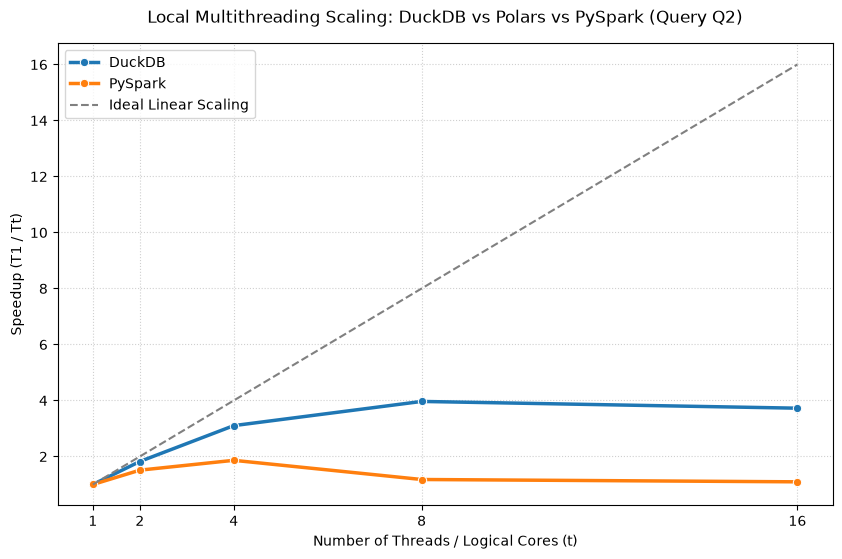

In [62]:
all_scaling_data = duckdb_test_data + pyspark_test_data
df_speedup_report = plot_scaling_results(all_scaling_data, TEST_THREADS)

### Task 5: Spark on Dataproc

Use the infrastructure from Phase 1 to run selected PySpark queries on a Dataproc cluster.

Required comparison:

- local PySpark vs. Dataproc PySpark,
- your main dataset size, and optionally one larger stress-test size if Spark overhead or scaling is not visible,
- at least one explanation based on Spark execution characteristics such as partitions, shuffle, caching, or scheduling overhead.

You may use the same generated Parquet data, uploaded to GCS. Consider using the partitioned layout if your query filters by date or another partition column.

In [ ]:
# TODO: Add Dataproc-specific commands, notebook cells, or instructions used by your group.
# Do not hard-code credentials or project secrets in the notebook.

## Final notebook report

The rendered notebook is your final submission. You do not submit a separate report.

Before submitting, make sure this notebook contains:

- group id and selected data profile,
- link to this notebook in your fork,
- main dataset size (`N_ROWS`), schema summary, and physical layout,
- three query descriptions with hypotheses,
- local benchmark table for Pandas 3.0 default backend, Pandas 3.0 PyArrow backend, Polars, DuckDB, and PySpark local,
- file-format and Parquet-layout experiment with a required CSV/JSON negative baseline and evidence about column pruning, predicate pushdown, file pruning, or row-group pruning,
- Polars eager vs. lazy vs. streaming vs. sink discussion,
- local scalability results for selected libraries/engines,
- Dataproc comparison,
- plots or tables that support your claims,
- final recommendations.

Do not commit generated data files, benchmark outputs, credentials, or local environment files.


### Final answers

Fill in the cells below. These answers should be visible in the rendered notebook.

In [ ]:
from IPython.display import Markdown, display

def display_answer(title, text):
    display(Markdown(f"**{title}**\n\n{text.strip()}"))

# TODO FINAL 1: Which query best exposes the difference between DataFrame and SQL engines?
FINAL_ANSWER_1 = """
TODO: Write your answer here.
"""
display_answer("Final answer 1", FINAL_ANSWER_1)

In [ ]:
from IPython.display import Markdown, display

def display_answer(title, text):
    display(Markdown(f"**{title}**\n\n{text.strip()}"))

# TODO FINAL 2: Which query is most memory-sensitive?
FINAL_ANSWER_2 = """
TODO: Write your answer here. Refer to measured peak memory and dataset/query shape.
"""
display_answer("Final answer 2", FINAL_ANSWER_2)

In [ ]:
from IPython.display import Markdown, display

def display_answer(title, text):
    display(Markdown(f"**{title}**\n\n{text.strip()}"))

# TODO FINAL 3: Did lazy execution change the amount of data read or materialized?
FINAL_ANSWER_3 = """
TODO: Write your answer here. Refer to predicate/projection pushdown or query plans if available.
"""
display_answer("Final answer 3", FINAL_ANSWER_3)

In [ ]:
from IPython.display import Markdown, display

def display_answer(title, text):
    display(Markdown(f"**{title}**\n\n{text.strip()}"))

# TODO FINAL 4: Did streaming collection reduce memory, runtime, or both?
FINAL_ANSWER_4 = """
TODO: Write your answer here. Distinguish collect(engine="streaming") from sink_parquet(...).
"""
display_answer("Final answer 4", FINAL_ANSWER_4)

In [ ]:
from IPython.display import Markdown, display

def display_answer(title, text):
    display(Markdown(f"**{title}**\n\n{text.strip()}"))

# TODO FINAL 5: When was a streaming sink more appropriate than collecting the result?
FINAL_ANSWER_5 = """
TODO: Write your answer here. Mention output size and whether the final result needed to be materialized in Python.
"""
display_answer("Final answer 5", FINAL_ANSWER_5)

In [ ]:
from IPython.display import Markdown, display

def display_answer(title, text):
    display(Markdown(f"**{title}**\n\n{text.strip()}"))

# TODO FINAL 6: Did local Spark behave as expected compared with the single-node engines?
FINAL_ANSWER_6 = """
TODO: Write your answer here. Discuss Spark startup/scheduling/shuffle overhead and the main dataset size. Mention optional larger stress-test sizes only if you used them.
"""
display_answer("Final answer 6", FINAL_ANSWER_6)

In [ ]:
from IPython.display import Markdown, display

def display_answer(title, text):
    display(Markdown(f"**{title}**\n\n{text.strip()}"))

# TODO FINAL 7: At what dataset size or query shape would you move from local processing to a cluster?
FINAL_ANSWER_7 = """
TODO: Write your answer here. State a concrete decision boundary supported by your measurements.
"""
display_answer("Final answer 7", FINAL_ANSWER_7)

In [ ]:
from IPython.display import Markdown, display

def display_answer(title, text):
    display(Markdown(f"**{title}**\n\n{text.strip()}"))

# TODO FINAL 8: How did Pandas default backend compare with the PyArrow dtype backend?
FINAL_ANSWER_8 = """
TODO: Write your answer here. Mention runtime, memory, dtypes, and whether string-heavy or IO-heavy queries changed the result.
"""
display_answer("Final answer 8", FINAL_ANSWER_8)
